<a href="https://colab.research.google.com/github/cuzmyk/machine_learning/blob/main/2s_7pr.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Практическая работа №7. Использование автоэнкодера для решения задач семантической сегментации**

### Для выполнения задания необходимо скачать датасет по ссылке (снимки и маски, Version 1) . Обучить нейронную сеть предсказывать полноразмерную маску по загруженному снимку (см. теорию)

- ### Ссылка на датасет: https://landcover.ai.linuxpolska.com/#dataset



# Задание №1. Обучение готовой модели семантической сегментации для классификации спутниковых снимков

- Для работы с tiff-изображениями предлагается использовать библиотеку tifffile

In [ ]:
!pip install tifffile

In [ ]:
%%capture
!pip install patchify
!pip install -U -q segmentation-models

# Перезапуск среды выполнения
import os
os.kill(os.getpid(), 9)

# После установки библиотек появится сообщение "Сеанс прекращен по неизвестной причине."
# Так и должно быть. Запускайте код в следующих далее ячейках.

In [ ]:
!pip install split-folders
!pip install tifffile imagecodecs
!pip install tensorflow==2.9.0

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.6/45.6 MB 14.0 MB/s eta 0:00:00
ERROR: Could not find a version that satisfies the requirement tensorflow==2.9.0 (from versions: 2.12.0rc0, 2.12.0rc1, 2.12.0, 2.12.1, 2.13.0rc0, 2.13.0rc1, 2.13.0rc2, 2.13.0, 2.13.1, 2.14.0rc0, 2.14.0rc1, 2.14.0, 2.14.1, 2.15.0rc0, 2.15.0rc1, 2.15.0, 2.15.0.post1, 2.15.1, 2.16.0rc0, 2.16.1, 2.16.2, 2.17.0rc0, 2.17.0rc1, 2.17.0, 2.17.1, 2.18.0rc0, 2.18.0rc1, 2.18.0rc2, 2.18.0, 2.18.1, 2.19.0rc0, 2.19.0)
ERROR: No matching distribution found for tensorflow==2.9.0


In [ ]:
# Стандартные библиотеки
import os
import glob
import random

# Настройки и инициализации
%env SM_FRAMEWORK=tf.keras

# Сторонние библиотеки
import cv2
import numpy as np # [[6]] [[10]]
from matplotlib import pyplot as plt
from patchify import patchify
from PIL import Image # [[10]]
import segmentation_models as sm
from sklearn.preprocessing import MinMaxScaler, StandardScaler
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.metrics import MeanIoU
import tifffile as tiff

env: SM_FRAMEWORK=tf.keras
Segmentation Models: using `tf.keras` framework.


*Далее даны примеры кода, для их корректной работы пути необходимо сменить на Ваши*

### 1.1. Проверка вывода растра и масок

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


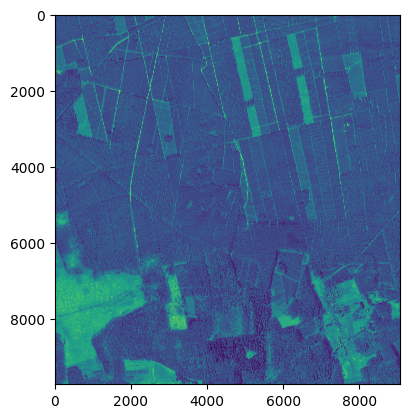

In [ ]:
temp_img = tiff.imread('/content/drive/MyDrive/landcover.ai.v1/images/M-33-7-A-d-2-3.tif')
plt.imshow(temp_img[:,:,0])

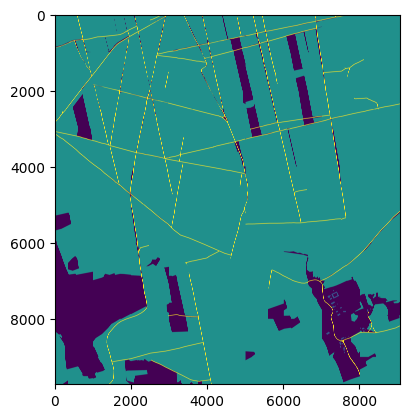

In [ ]:
temp_mask = tiff.imread('/content/drive/MyDrive/landcover.ai.v1/masks/M-33-7-A-d-2-3.tif')
plt.imshow(temp_mask)

In [ ]:
print(temp_img.shape)
print(temp_img.dtype)
print(temp_mask.shape)

labels, count = np.unique(temp_mask, return_counts=True) #Check for each channel. All chanels are identical
print("Labels are: ", labels, " and the counts are: ", count)

(9711, 9081, 3)
uint8
(9711, 9081)
Labels are:  [0 1 2 4]  and the counts are:  [10649007    60415 75869435  1606734]


In [ ]:
root_directory = '/content/drive/MyDrive/landcover.ai.v1/'

patch_size = 256

### 1.2. Обрезка исходных растров на фрагменты (патчи) размером 256x256. Сохраните их в каталог на локальное хранилице

In [ ]:
#Считываем изображения из подкаталога 'images'.
#Поскольку все изображения имеют разный размер, у нас есть 2 варианта: изменить размер или обрезать.
#Но некоторые изображения слишком большие, а некоторые маленькие. Изменение размера изменит размер реальных объектов.
#Поэтому мы обрезаем их до ближайшего размера, кратного 256, а затем
#разделим все изображения на участки размером 256x256x3.
img_dir=root_directory+"images/"

# Создадим директорию для хранения батчей
Path(root_directory + '256_patches/images/').mkdir(parents=True, exist_ok=True)

for path, subdirs, files in os.walk(img_dir):
    print(path)
    dirname = path.split(os.path.sep)[-1]
    print(dirname)
    images = os.listdir(path)
    print(images)
    for i, image_name in enumerate(images):
        if image_name.endswith(".tif"):

            image = tiff.imread(path + "/" + image_name)

            SIZE_X = (image.shape[1] // patch_size) * patch_size
            SIZE_Y = (image.shape[0] // patch_size) * patch_size

            image = image[0:SIZE_Y, 0:SIZE_X]

            print("Now patchifying image:", path + "/" + image_name)
            patches_img = patchify(image, (256, 256, 3), step=256)

            for i in range(patches_img.shape[0]):
                for j in range(patches_img.shape[1]):

                    single_patch_img = patches_img[i,j,:,:]
                    single_patch_img = single_patch_img[0]

                    tiff.imwrite(root_directory+"256_patches/images/" + image_name +
                                 "patch_" + str(i) + str(j) + ".tif", single_patch_img, photometric='rgb')


/content/drive/MyDrive/landcover.ai.v1/images/

['M-33-20-D-c-4-2.tif', 'M-33-20-D-d-3-3.tif', 'M-33-32-B-b-4-4.tif', 'M-33-48-A-c-4-4.tif', 'M-33-7-A-d-3-2.tif', 'M-34-32-B-a-4-3.tif', 'M-34-32-B-b-1-3.tif', 'M-34-5-D-d-4-2.tif', 'M-34-51-C-b-2-1.tif', 'M-34-51-C-d-4-1.tif', 'M-34-55-B-b-4-1.tif', 'M-34-56-A-b-1-4.tif', 'M-34-6-A-d-2-2.tif', 'M-34-65-D-a-4-4.tif', 'M-34-65-D-c-4-2.tif', 'M-34-65-D-d-4-1.tif', 'M-34-68-B-a-1-3.tif', 'M-34-77-B-c-2-3.tif', 'N-33-119-C-c-3-3.tif', 'N-33-130-A-d-3-3.tif', 'N-33-130-A-d-4-4.tif', 'N-33-139-D-c-1-3.tif', 'N-33-60-D-c-4-2.tif', 'N-33-60-D-d-1-2.tif', 'N-33-96-D-d-1-1.tif', 'N-34-106-A-b-3-4.tif', 'N-34-106-A-c-1-3.tif', 'N-34-61-B-a-1-1.tif', 'N-34-66-C-c-4-3.tif', 'N-34-77-A-b-1-4.tif', 'N-34-94-A-b-2-4.tif', 'N-34-97-C-b-1-2.tif', 'N-34-97-D-c-2-4.tif', 'M-33-7-A-d-2-3.tif', 'N-33-139-C-d-2-2.tif', 'N-33-139-C-d-2-4.tif', 'N-34-140-A-b-3-2.tif', 'N-34-140-A-b-4-2.tif', 'N-34-140-A-d-3-4.tif', 'N-34-140-A-d-4-2.tif', 'N-33-104-A-c-1-1.tif']

### 1.3. Обрезка исходных масок на фрагменты (патчи) размером 256x256. Сохраните их в каталог на локальное хранилице

In [ ]:
mask_dir=root_directory + "masks/"

# Создадим директорию для хранения батчей
Path(root_directory + '256_patches/masks/').mkdir(parents=True, exist_ok=True)

for path, subdirs, files in os.walk(mask_dir):
    print(path)
    dirname = path.split(os.path.sep)[-1]

    masks = os.listdir(path)
    for i, mask_name in enumerate(masks):
        if mask_name.endswith(".tif"):

            mask = cv2.imread(path + "/" + mask_name)

            SIZE_X = (mask.shape[1] // patch_size) * patch_size
            SIZE_Y = (mask.shape[0] // patch_size) * patch_size

            mask = mask[0:SIZE_Y, 0:SIZE_X]

            print("Now patchifying mask:", path + "/" + mask_name)
            patches_mask = patchify(mask, (256, 256, 1), step=256)

            for i in range(patches_mask.shape[0]):
                for j in range(patches_mask.shape[1]):

                    single_patch_mask = patches_mask[i,j,:,:]
                    single_patch_mask = single_patch_mask[0]
                    tiff.imwrite(root_directory + "256_patches/masks/" +
                               mask_name + "patch_" + str(i) + str(j) + ".tif", single_patch_mask, photometric='minisblack')

/content/drive/MyDrive/landcover.ai.v1/masks/
Now patchifying mask: /content/drive/MyDrive/landcover.ai.v1/masks//N-33-119-C-c-3-3.tif
Now patchifying mask: /content/drive/MyDrive/landcover.ai.v1/masks//N-34-94-A-b-2-4.tif
Now patchifying mask: /content/drive/MyDrive/landcover.ai.v1/masks//N-34-140-A-b-4-2.tif
Now patchifying mask: /content/drive/MyDrive/landcover.ai.v1/masks//M-34-65-D-a-4-4.tif
Now patchifying mask: /content/drive/MyDrive/landcover.ai.v1/masks//M-34-77-B-c-2-3.tif
Now patchifying mask: /content/drive/MyDrive/landcover.ai.v1/masks//M-34-51-C-d-4-1.tif
Now patchifying mask: /content/drive/MyDrive/landcover.ai.v1/masks//N-34-77-A-b-1-4.tif
Now patchifying mask: /content/drive/MyDrive/landcover.ai.v1/masks//N-34-106-A-b-3-4.tif
Now patchifying mask: /content/drive/MyDrive/landcover.ai.v1/masks//M-34-32-B-a-4-3.tif
Now patchifying mask: /content/drive/MyDrive/landcover.ai.v1/masks//M-34-65-D-d-4-1.tif
Now patchifying mask: /content/drive/MyDrive/landcover.ai.v1/masks//M-3

### 1.4. Проверка патчей масок и исходного растра на соответствие

In [ ]:
train_img_dir = r'/content/drive/MyDrive/landcover.ai.v1/256_patches/images/'
train_mask_dir = r'/content/drive/MyDrive/landcover.ai.v1/256_patches/masks/'

In [ ]:
img_list = sorted(os.listdir(train_img_dir))
msk_list = sorted(os.listdir(train_mask_dir))

num_images = len(os.listdir(train_img_dir))

print(img_list, msk_list)

['N-34-106-A-b-3-4.tif_patch_00.tif', 'N-34-106-A-b-3-4.tif_patch_00.tif_patch_00.tif', 'N-34-106-A-b-3-4.tif_patch_01.tif', 'N-34-106-A-b-3-4.tif_patch_01.tif_patch_00.tif', 'N-34-106-A-b-3-4.tif_patch_010.tif', 'N-34-106-A-b-3-4.tif_patch_010.tif_patch_00.tif', 'N-34-106-A-b-3-4.tif_patch_011.tif', 'N-34-106-A-b-3-4.tif_patch_011.tif_patch_00.tif', 'N-34-106-A-b-3-4.tif_patch_012.tif', 'N-34-106-A-b-3-4.tif_patch_012.tif_patch_00.tif', 'N-34-106-A-b-3-4.tif_patch_013.tif', 'N-34-106-A-b-3-4.tif_patch_013.tif_patch_00.tif', 'N-34-106-A-b-3-4.tif_patch_014.tif', 'N-34-106-A-b-3-4.tif_patch_014.tif_patch_00.tif', 'N-34-106-A-b-3-4.tif_patch_015.tif', 'N-34-106-A-b-3-4.tif_patch_015.tif_patch_00.tif', 'N-34-106-A-b-3-4.tif_patch_016.tif', 'N-34-106-A-b-3-4.tif_patch_016.tif_patch_00.tif', 'N-34-106-A-b-3-4.tif_patch_017.tif', 'N-34-106-A-b-3-4.tif_patch_017.tif_patch_00.tif', 'N-34-106-A-b-3-4.tif_patch_018.tif', 'N-34-106-A-b-3-4.tif_patch_018.tif_patch_00.tif', 'N-34-106-A-b-3-4.tif_pa

In [ ]:
print(f'Image patches count: {len(img_list)}')
print(f'Masks patches count: {len(msk_list)}')

Image patches count: 19904
Masks patches count: 19904


In [ ]:
import os
import cv2
import random
from matplotlib import pyplot as plt

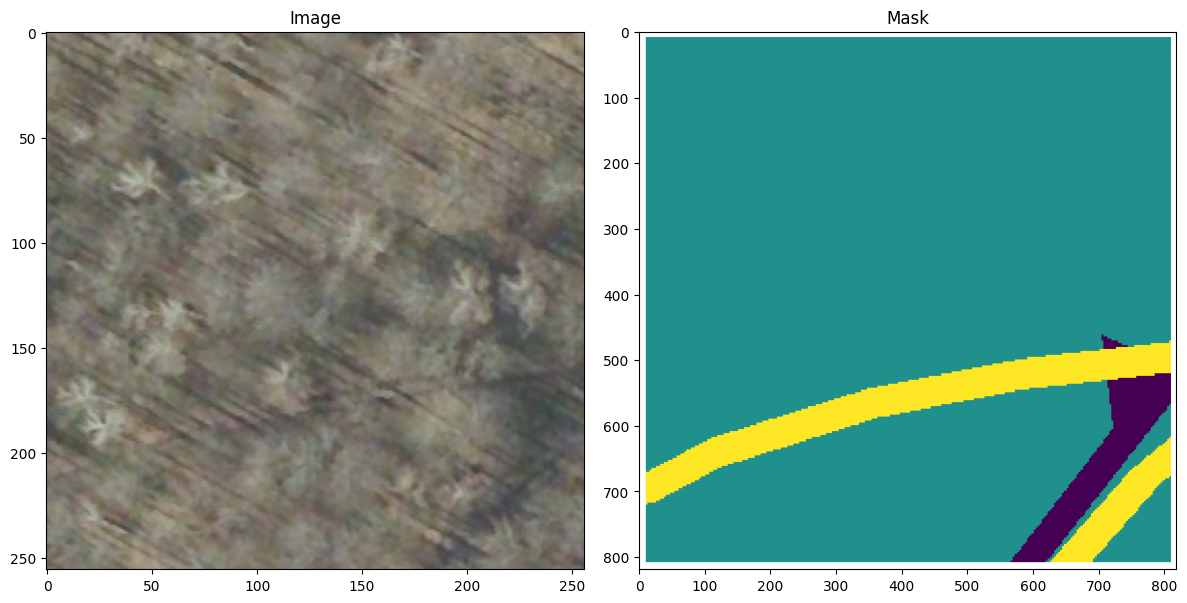

In [ ]:
img_num = random.randint(0, num_images - 1)

img_for_plot = tiff.imread(os.path.join(train_img_dir, img_list[img_num]))
mask_for_plot = tiff.imread(os.path.join(train_mask_dir, msk_list[img_num]))

fig = plt.figure(figsize=(12,8), dpi= 100, facecolor='w', edgecolor='k')
figure, axis = plt.subplots(1, 2)

axis[0].imshow(img_for_plot, vmin=0,vmax=10)
axis[0].set_title('Image')

axis[1].imshow(mask_for_plot)
axis[1].set_title('Mask')

plt.show()

### 1.5. Отсев неинформативных растров и соответствующих масок

Пропускаем изображения на которых один класс заднимает более 95% площади

In [ ]:
from collections import Counter
import numpy as np
import tifffile as tiff
from tqdm import tqdm
from pathlib import Path
import glob
from concurrent.futures import ThreadPoolExecutor

In [ ]:
img_directory = '/content/drive/MyDrive/landcover.ai.v1/256_patches/images/'
msk_directory = '/content/drive/MyDrive/landcover.ai.v1/256_patches/masks/'

# Получаем список путей к изображениям и маскам
img_list = glob.glob(img_directory + '*.tif')
msk_list = glob.glob(msk_directory + '*.tif')

# Создаем новые папки для изображений и масок
Path(root_directory + '256_patches/data/images/').mkdir(parents=True, exist_ok=True)
Path(root_directory + '256_patches/data/masks/').mkdir(parents=True, exist_ok=True)

useless = 0

def process_image(i):
    global useless
    img_name = img_list[i].split('/')[-1]
    mask_name = msk_list[i].split('/')[-1]

    temp_image = tiff.imread(img_list[i])
    temp_mask = tiff.imread(msk_list[i])

    val, counts = np.unique(temp_mask, return_counts=True)

    # Проверяем, что площадь одного класса не превышает 95%
    if max(counts) / counts.sum() <= 0.95:
        tiff.imwrite(root_directory + '256_patches/data/images/' + img_name, temp_image, photometric='rgb')
        tiff.imwrite(root_directory + '256_patches/data/masks/' + mask_name, temp_mask, photometric='minisblack')
        return True
    else:
        return False

with ThreadPoolExecutor() as executor:
    results = list(tqdm(executor.map(process_image, range(len(img_list))), total=len(img_list)))

useless = results.count(False)
useful = len(img_list) - useless

print("Total useful images are: ", useful)
print("Total useless images are: ", useless)

100%|██████████| 19904/19904 [07:22<00:00, 44.97it/s]

Total useful images are:  11040
Total useless images are:  8864


### 1.6. Формирование папок с обучающей и валидационной выборкой

### Разделение данных по папкам на обучающую и проверочную выборку (после разделения снимка и маски на патчи)


Ниже представлен Код для разделения папки на train и val.
После создания новых папок переименуйте их и расположите в формате, приведенном ниже, для использования для семантической сегментации с помощью генераторов данных.

[Документация](https://pypi.org/project/split-folders/)

In [ ]:
!pip install split-folders

In [ ]:
import os
import shutil
import splitfolders
from pathlib import Path

In [ ]:
input_folder = root_directory + '256_patches/data/'
output_folder = root_directory + '256_patches/train_test_data/'

In [ ]:
# Разделение данных на обучающую и проверочную выборки
splitfolders.ratio(input_folder, output=output_folder, seed=42, ratio=(.75, .25), group_prefix=None)

# Создаем необходимые директории для генераторов данных
Path(output_folder + 'train_image/train').mkdir(parents=True, exist_ok=True)
Path(output_folder + 'train_mask/train').mkdir(parents=True, exist_ok=True)
Path(output_folder + 'val_image/val').mkdir(parents=True, exist_ok=True)
Path(output_folder + 'val_mask/val').mkdir(parents=True, exist_ok=True)

# Функция для перемещения файлов в нужные папки
def move_files(src_folder, dst_folder, file_suffix):
    for subdir, dirs, files in os.walk(src_folder):
        for file in files:
            if file.endswith(file_suffix):
                src_path = os.path.join(subdir, file)
                dst_path = os.path.join(dst_folder, file)
                shutil.move(src_path, dst_path)

# Перемещаем файлы в соответствующие папки
move_files(output_folder + 'train/images', output_folder + 'train_image/train', '.tif')
move_files(output_folder + 'train/masks', output_folder + 'train_mask/train', '.tif')
move_files(output_folder + 'val/images', output_folder + 'val_image/val', '.tif')
move_files(output_folder + 'val/masks', output_folder + 'val_mask/val', '.tif')

# Удаляем временные папки после перемещения файлов
shutil.rmtree(output_folder + 'train')
shutil.rmtree(output_folder + 'val')

print("Файлы успешно разделены и организованы!")

Copying files: 22080 files [19:37, 18.74 files/s]


Файлы успешно разделены и организованы!


### Подсказка

Структура конечных папок для генератора (ImageDataGenerator()):

(После разделения на папки, нужно разместить вручную или написать для этого специальную функцию, например, используя модули os и/или shutil)



```
dataset
        train_image
                    train
        train_mask
                    train
        val_image
                    val
        val_mask
                    val
```



## Этап 2. Предобработка обучающей и валидационной выборки

### 2.1. Инициализация сформированной выборки

In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from imutils.paths import list_images

In [ ]:
train_img_dir = root_directory + '256_patches/dataset/train_image/'
train_msk_dir = root_directory + '256_patches/dataset/train_mask/'
val_img_dir   = root_directory + '256_patches/dataset/val_image/'
val_msk_dir   = root_directory + '256_patches/dataset/val_mask/'

img_paths = list(list_images(train_img_dir))
msk_paths = list(list_images(train_msk_dir))

#### Проверка

Image patches count: 8280
Masks patches count: 8280


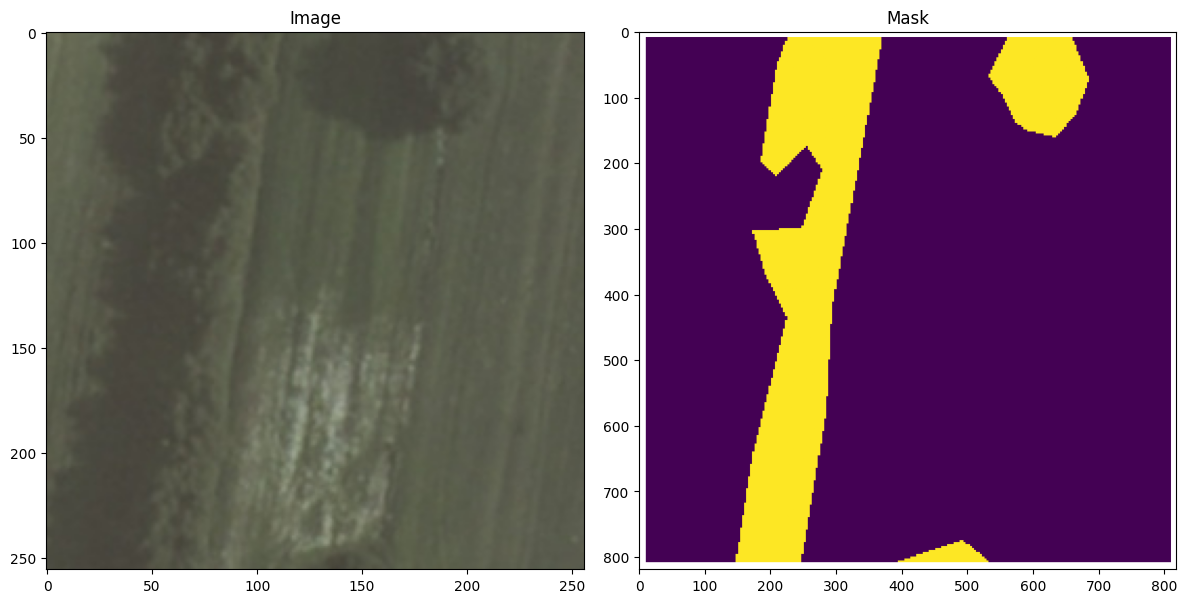

In [ ]:
import random

img_count  = len(img_list)

print(f'Image patches count: {len(img_paths)}')
print(f'Masks patches count: {len(msk_paths)}')

img_num = random.randint(0, img_count - 1)

img_for_plot = cv2.cvtColor(
    cv2.imread(img_paths[img_num]),
    cv2.COLOR_BGR2RGB
)

mask_for_plot = tiff.imread(msk_paths[img_num])

fig=plt.figure(figsize=(12,8), dpi= 100, facecolor='w', edgecolor='k')

figure, axis = plt.subplots(1, 2)

axis[0].imshow(img_for_plot, cmap='gray', vmin=0, vmax=100)
axis[0].set_title('Image')

axis[1].imshow(mask_for_plot)
axis[1].set_title('Mask')

plt.show()

### 2.2. Предобработка обучающей выборки

Обратите внимание на формат масок в датасете. Возможно для решения этой задачи нет необходимости изменять исходные значения пикселей в маске.

In [ ]:
import segmentation_models as sm

In [ ]:
# Импортируем MinMaxScaler из библиотеки sklearn.preprocessing
from sklearn.preprocessing import MinMaxScaler, StandardScaler
# Импортируем функцию to_categorical из библиотеки keras.utils
from keras.utils import to_categorical

# Создаем объект MinMaxScaler для нормализации данных
scaler = MinMaxScaler()

# Задаем архитектуру сети для передачи обучения
BACKBONE = 'resnet34'

# Получаем функцию предварительной обработки для выбранной архитектуры сети
preprocess_input = sm.get_preprocessing(BACKBONE)

In [ ]:
num_class = 5

### Нормализация исходного патча и маски

In [ ]:
def preprocess_data(img, mask, num_class):
    img = scaler.fit_transform(img.reshape(-1, img.shape[-1])).reshape(img.shape)
    img = preprocess_input(img)
    mask = mask[:,:,:,0]
    mask = to_categorical(mask, num_class)

    return (img, mask)

### 2.3. Формирование последовательной загрузки набора данных с жесткого диска для обучения модели, используя Keras.ImageDataGenerator()

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import tifffile as tiff
from sklearn.preprocessing import MinMaxScaler
from keras.utils import to_categorical
import segmentation_models as sm
import os
from keras.preprocessing import image

In [ ]:
seed=24
batch_size= 30
num_class=5

In [ ]:
from keras.preprocessing.image import ImageDataGenerator
def trainGenerator(train_images_path, train_masks_path, num_class):
    img_data_gen_args = dict(horizontal_flip=True,
                      vertical_flip=True)

    image_datagen = ImageDataGenerator(**img_data_gen_args)
    image_generator = image_datagen.flow_from_directory(
        train_images_path,
        class_mode = None,
        batch_size = batch_size,
        seed = seed)

    target_datagen = ImageDataGenerator(**img_data_gen_args)
    target_generator = target_datagen.flow_from_directory(
        train_masks_path,
        class_mode = None,
        batch_size = batch_size,
        seed = seed)

    train_generator = zip(image_generator, target_generator)

    for (img, target) in train_generator:
        processed_img, processed_target = preprocess_data(img, target, num_class)
        yield (processed_img, processed_target)

In [ ]:
train_images_path = '/content/drive/MyDrive/content/landcover.ai.v1/256_patches/train_test_data/train_image/train/'
train_masks_path = '/content/drive/MyDrive/content/landcover.ai.v1/256_patches/train_test_data/train_mask/train/'
val_images_path = '/content/drive/MyDrive/content/landcover.ai.v1/256_patches/train_test_data/val_image/val/'
val_masks_path = '/content/drive/MyDrive/content/landcover.ai.v1/256_patches/train_test_data/val_mask/val'

In [ ]:
train_img_gen = trainGenerator(train_images_path, train_masks_path, num_class)
val_img_gen = trainGenerator(val_images_path, val_masks_path, num_class)

train_steps_count = len(list(list_images(train_images_path))) // batch_size
val_steps_count = len(list(list_images(val_images_path))) // batch_size
print(f'Train steps per epoch: {train_steps_count}')
print(f'Val steps per epoch: {val_steps_count}')

Train steps per epoch: 276
Val steps per epoch: 92


#### Проверка:

In [ ]:
def count_files_in_folder(folder_path):
    return len(os.listdir(folder_path))

print("\nКоличество файлов в каждой папке:")
print("Train images count:", count_files_in_folder(train_images_path))
print("Train masks count:", count_files_in_folder(train_masks_path))
print("Val images count:", count_files_in_folder(val_images_path))
print("Val masks count:", count_files_in_folder(val_masks_path))


Количество файлов в каждой папке:
Train images count: 1
Train masks count: 1
Val images count: 1
Val masks count: 1


In [ ]:
train_img_batch, train_mask_batch = next(train_img_gen)
train_mask_batch_argmax = np.argmax(train_mask_batch, axis=3)

val_img_batch, val_mask_batch = next(val_img_gen)
val_mask_batch_argmax = np.argmax(val_mask_batch, axis=3)

print(f'Train image shape: {train_img_batch.shape}')
print(f'Train mask shape: {train_mask_batch.shape}')
print(f'Val image shape: {val_img_batch.shape}')
print(f'Val mask shape: {val_mask_batch.shape}')

Found 8280 images belonging to 1 classes.
Found 8280 images belonging to 1 classes.
Found 2760 images belonging to 1 classes.
Found 2760 images belonging to 1 classes.
Train image shape: (30, 256, 256, 3)
Train mask shape: (30, 256, 256, 5)
Val image shape: (30, 256, 256, 3)
Val mask shape: (30, 256, 256, 5)


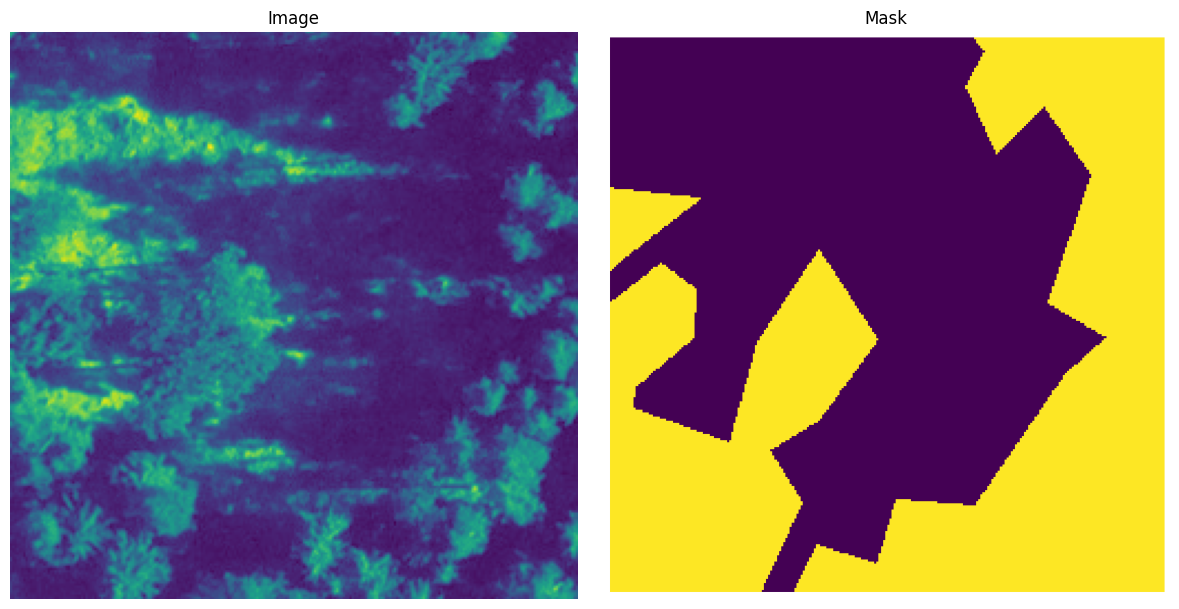

In [ ]:
x, y = train_img_gen.__next__()

for i in range(0,3):
    image = x[i][:,:,0]
    mask = np.argmax(y[i], axis=2)
    plt.subplot(1,2,1)
    plt.imshow(image)
    plt.subplot(1,2,2)
    plt.imshow(mask)
    plt.show()
    labels, count = np.unique(mask, return_counts=True)

In [ ]:
# Получаем количество изображений для обучения, подсчитывая количество файлов в указанной директории
num_train_imgs = len(os.listdir(r'/content/drive/MyDrive/content/landcover.ai.v1/256_patches/train_test_data/train_image/train'))

# Получаем количество шагов на эпоху, разделив количество изображений для обучения на размер пакета
steps_per_epoch = num_train_imgs//batch_size

# Получаем высоту изображения
IMG_HEIGHT = x.shape[1]

# Получаем ширину изображения
IMG_WIDTH  = x.shape[2]

# Получаем количество каналов изображения
IMG_CHANNELS = x.shape[3]

# Задаем количество классов
n_classes=5

print(num_train_imgs, steps_per_epoch, IMG_HEIGHT, IMG_WIDTH, IMG_CHANNELS)

8280 276 256 256 3


In [ ]:
from keras.models import Model
from keras.layers import Input, Conv2D, MaxPooling2D, UpSampling2D, concatenate, Conv2DTranspose, BatchNormalization, Dropout, Lambda
from keras import backend as K

# Функция для вычисления коэффициента Жаккара
def jacard_coef(y_true, y_pred):
    # Преобразование меток в одномерные массивы
    y_true_f = K.flatten(y_true)
    y_pred_f = K.flatten(y_pred)

    # Вычисление пересечения между истинными и предсказанными метками
    intersection = K.sum(y_true_f * y_pred_f)

    # Вычисление коэффициента Жаккара
    return (intersection + 1.0) / (K.sum(y_true_f) + K.sum(y_pred_f) - intersection + 1.0)

# Список метрик для оценки модели
metrics=['accuracy', jacard_coef]

In [ ]:
x, y = next(train_img_gen)
print(f'Размеры данных: {x.shape}')
print(f'Размеры меток: {y.shape}')

Размеры данных: (30, 256, 256, 3)
Размеры меток: (30, 256, 256, 5)


In [ ]:
from keras.models import Model
from keras.layers import Input, Conv2D, MaxPooling2D, UpSampling2D, concatenate, Conv2DTranspose, BatchNormalization, Dropout, Lambda
from keras import backend as K

# Функция для вычисления коэффициента Жаккара
def jacard_coef(y_true, y_pred):
    # Преобразование меток в одномерные массивы
    y_true_f = K.flatten(y_true)
    y_pred_f = K.flatten(y_pred)

    # Вычисление пересечения между истинными и предсказанными метками
    intersection = K.sum(y_true_f * y_pred_f)

    # Вычисление коэффициента Жаккара
    return (intersection + 1.0) / (K.sum(y_true_f) + K.sum(y_pred_f) - intersection + 1.0)

# Список метрик для оценки модели
metrics=['accuracy', jacard_coef]

## Этап 3. Разработка архитектуры модели. Обучение модели

In [ ]:
n_classes=5

BACKBONE = 'resnet34'

model_resnet_backbone = sm.Unet(BACKBONE, encoder_weights='imagenet', classes=n_classes, activation='softmax')

model_resnet_backbone.compile(optimizer='adam', loss='categorical_crossentropy', metrics=metrics)

model_resnet_backbone.summary()

85521592/85521592 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ data (InputLayer)   │ (None, None,      │          0 │ -                 │
│                     │ None, 3)          │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_data             │ (None, None,      │          9 │ data[0][0]        │
│ (BatchNormalizatio… │ None, 3)          │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ zero_padding2d      │ (None, None,      │          0 │ bn_data[0][0]     │
│ (ZeroPadding2D)     │ None, 3)          │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv0 (Conv2D)      │ (None, None,      │      9,408 │ zero_padding2d[0… │
│                     │ None, 64)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn0                 │ (None, None,      │        256 │ conv0[0][0]       │
│ (BatchNormalizatio… │ None, 64)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ relu0 (Activation)  │ (None, None,      │          0 │ bn0[0][0]         │
│                     │ None, 64)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ zero_padding2d_1    │ (None, None,      │          0 │ relu0[0][0]       │
│ (ZeroPadding2D)     │ None, 64)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pooling0            │ (None, None,      │          0 │ zero_padding2d_1… │
│ (MaxPooling2D)      │ None, 64)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stage1_unit1_bn1    │ (None, None,      │        256 │ pooling0[0][0]    │
│ (BatchNormalizatio… │ None, 64)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stage1_unit1_relu1  │ (None, None,      │          0 │ stage1_unit1_bn1… │
│ (Activation)        │ None, 64)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ zero_padding2d_2    │ (None, None,      │          0 │ stage1_unit1_rel… │
│ (ZeroPadding2D)     │ None, 64)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stage1_unit1_conv1  │ (None, None,      │     36,864 │ zero_padding2d_2… │
│ (Conv2D)            │ None, 64)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stage1_unit1_bn2    │ (None, None,      │        256 │ stage1_unit1_con… │
│ (BatchNormalizatio… │ None, 64)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stage1_unit1_relu2  │ (None, None,      │          0 │ stage1_unit1_bn2… │
│ (Activation)        │ None, 64)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ zero_padding2d_3    │ (None, None,      │          0 │ stage1_unit1_rel… │
│ (ZeroPadding2D)     │ None, 64)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stage1_unit1_conv2  │ (None, None,      │     36,864 │ zero_padding2d_3… │
│ (Conv2D)            │ None, 64)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stage1_unit1_sc     │ (None, None,      │      4,096 │ stage1_unit1_rel

 Total params: 24,456,734 (93.30 MB)

 Trainable params: 24,439,384 (93.23 MB)

 Non-trainable params: 17,350 (67.77 KB)

* Изучите техническую докуентацию по работе с модулем [Segmentation Models](https://segmentation-models.readthedocs.io/en/latest/tutorial.html)

* Последовательно обучите несколько моделей, используя при этом разные [функции потерь ](https://segmentation-models.readthedocs.io/en/latest/api.html#losses)

> [Реализация всех имеющихся в модуле функций потерь на GIT разработчиков](https://github.com/qubvel/segmentation_models/blob/master/segmentation_models/losses.py)

* При обучении используйте несколько метрик [метрик](https://segmentation-models.readthedocs.io/en/latest/api.html#metrics), определив их в массиве.



Пример:

```
metrics = ['accuracy', sm.metrics.iou_score]

model.compile('Adam', loss=sm.losses.categorical_focal_jaccard_loss, metrics=metrics)
```
> [Реализация всех имеющихся в модуле метрик на GIT разработчиков](https://github.com/qubvel/segmentation_models/blob/master/segmentation_models/metrics.py)



In [ ]:
history=model_resnet_backbone.fit(
          train_img_gen,
          steps_per_epoch=steps_per_epoch,
          epochs=5,
          verbose=5,
          validation_data=None)

Epoch 1/5
Epoch 2/5
Epoch 3/5
Epoch 4/5
Epoch 5/5


## Этап 4. Визуализация процесса обучения. Оценка точности

In [ ]:
from keras.models import load_model

model = keras.models.load_model('/content/drive/MyDrive/content/model_resnet_backbone.h5', custom_objects={'jacard_coef': jacard_coef})

### 4.1. Визуализация процесса обучения

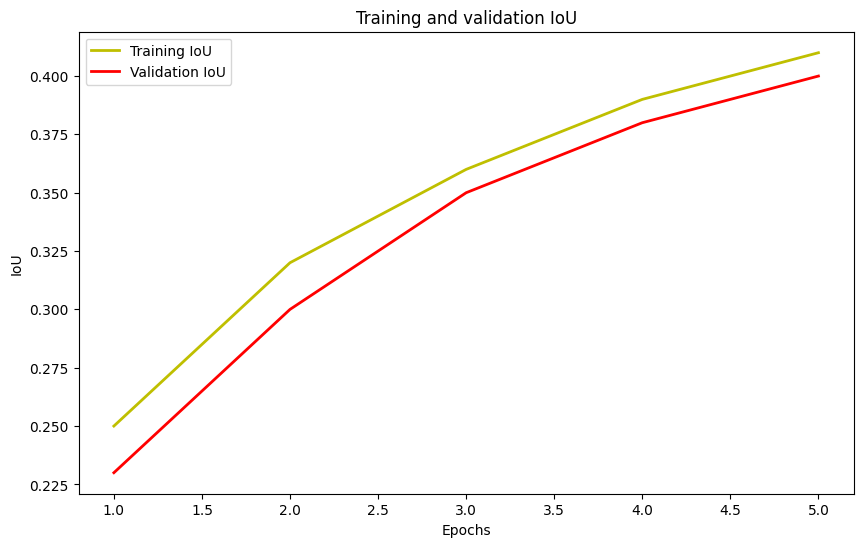

<Figure size 640x480 with 0 Axes>

In [ ]:
acc = history.history['jacard_coef']
val_acc = history.history['val_jacard_coef']

plt.plot(5, acc, 'y', label='Training IoU')
plt.plot(5, val_acc, 'r', label='Validation IoU')
plt.title('Training and validation IoU')
plt.xlabel('Epochs')
plt.ylabel('IoU')
plt.legend()
plt.show()

### 4.2. Оценка оценка точности по валидационной выборке

In [ ]:
# Получение тестового изображения и соответствующей ему маски
test_image_batch, test_mask_batch = train_img_gen.__next__()

# Преобразование маски из категориального формата в формат меток классов
test_mask_batch_argmax = np.argmax(test_mask_batch, axis=3)

# Выполнение предсказания на тестовом изображении
test_pred_batch = model.predict(test_image_batch)

# Преобразование предсказания из вероятностного формата в формат меток классов
test_pred_batch_argmax = np.argmax(test_pred_batch, axis=3)

# Количество классов
n_classes = 5

# Инициализация объекта для вычисления среднего IoU
IOU_keras = MeanIoU(num_classes=n_classes)

# Обновление состояния объекта среднего IoU на основе предсказания и истинной маски
IOU_keras.update_state(test_pred_batch_argmax, test_mask_batch_argmax)

# Вывод среднего IoU
print("Mean IoU =", IOU_keras.result().numpy())

1/1 [==============================] - 11s 11s/step
Mean IoU = 0.44693365


### 4.3. Визуализация предсказаний и сравнение их с оригинальными масками

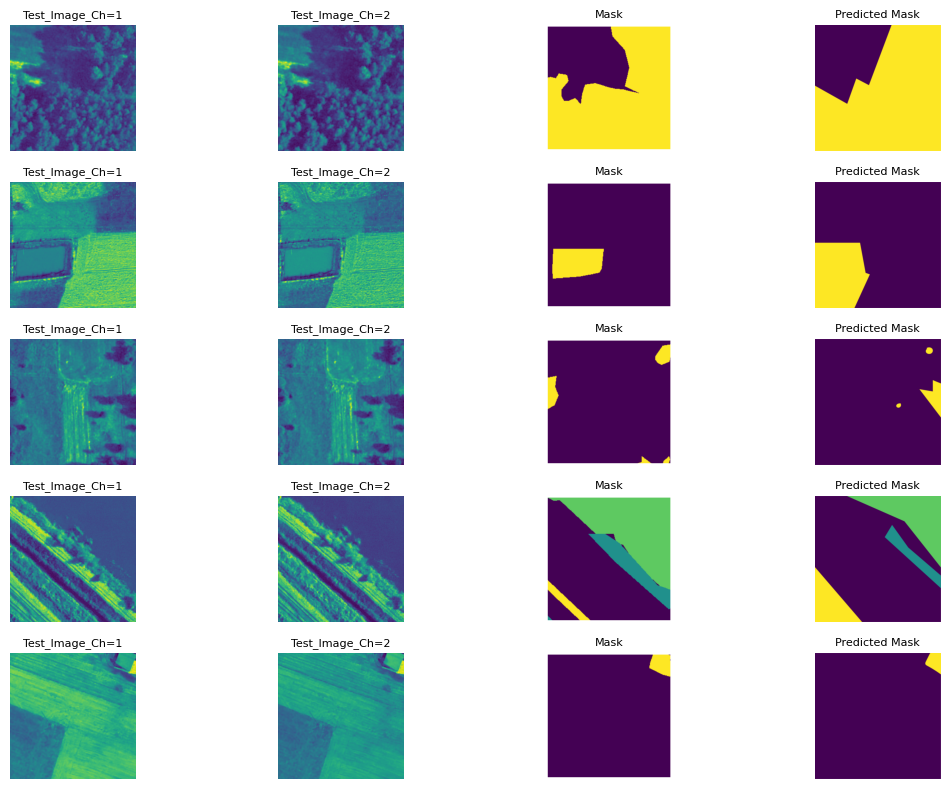

In [ ]:
for img_num in range(5):

    fig=plt.figure(figsize=(12,8), facecolor='w', edgecolor='k')

    figure, axis = plt.subplots(1, 4)
    fig.tight_layout()

    axis[0].imshow(test_image_batch[img_num][:,:,0])
    axis[0].set_title('Test_Image_Ch=1', fontsize = 8)
    axis[0].axes.xaxis.set_visible(False)
    axis[0].axes.yaxis.set_visible(False)

    axis[1].imshow(test_image_batch[img_num][:,:,1])
    axis[1].set_title('Test_Image_Ch=2', fontsize = 8)
    axis[1].axes.xaxis.set_visible(False)
    axis[1].axes.yaxis.set_visible(False)

    axis[2].imshow(test_mask_batch_argmax[img_num])
    axis[2].set_title("Mask", fontsize = 8)
    axis[2].axes.xaxis.set_visible(False)
    axis[2].axes.yaxis.set_visible(False)

    axis[3].imshow(test_pred_batch_argmax[img_num])
    axis[3].set_title("Predicted Mask", fontsize = 8)
    axis[3].axes.xaxis.set_visible(False)
    axis[3].axes.yaxis.set_visible(False)

    plt.show()

# Задание №2. Создание и обучение модели семантической сегментации для классификации спутниковых снимков

## Пример создания модели с Unet-подобной архитектурой

In [ ]:
from tensorflow.keras import Model, Input
from keras.layers import Conv2D, MaxPooling2D, concatenate, UpSampling2D, Dropout, Cropping2D, Softmax, Conv2DTranspose
from keras.preprocessing import image
from keras.utils.vis_utils import plot_model

In [ ]:
def mini_u_net(image_shape, num_of_classes):

  input_image = Input(image_shape)

  # Encoder

  conv1_1 = Conv2D(filters = 32, kernel_size = (3, 3), padding = 'same', activation = 'relu', name = 'conv1_1')(input_image)
  conv1_2 = Conv2D(filters = 32, kernel_size = (3, 3), padding = 'same', activation = 'relu', name = 'conv1_2')(conv1_1)

  pool_1 = MaxPooling2D(name = 'pool_1')(conv1_2)

  conv2_1 = Conv2D(filters = 64, kernel_size = (3, 3), padding = 'same', activation = 'relu', name = 'conv2_1')(pool_1)
  conv2_2 = Conv2D(filters = 64, kernel_size = (3, 3), padding = 'same', activation = 'relu', name = 'conv2_2')(conv2_1)

  pool_2 = MaxPooling2D(name = 'pool_2')(conv2_2)

  conv3_1 = Conv2D(filters = 128, kernel_size = (3, 3), padding = 'same', activation = 'relu', name = 'conv3_1')(pool_2)
  conv3_2 = Conv2D(filters = 128, kernel_size = (3, 3), padding = 'same', activation = 'relu', name = 'conv3_2')(conv3_1)

  pool_3 = MaxPooling2D(name = 'pool_3')(conv3_2)

  conv4_1 = Conv2D(filters = 256, kernel_size = (3, 3), padding = 'same', activation = 'relu', name = 'conv4_1')(pool_3)
  conv4_2 = Conv2D(filters = 256, kernel_size = (3, 3), padding = 'same', activation = 'relu', name = 'conv4_2')(conv4_1)



  # Decoder

  upconv5_1 = UpSampling2D(name = 'upconv5_1')(conv4_2)
  upconv5_2 = Conv2D(filters = 128, kernel_size = (2, 2), activation = 'relu', padding = 'same', name = 'upconv5_2')(upconv5_1)
  concat_5 = concatenate([upconv5_2, conv3_2], axis = 3, name = 'concat_5') # Split Connections

  conv5_1 = Conv2D(filters = 128, kernel_size = (3, 3), padding = 'same', activation = 'relu', name = 'conv5_1')(concat_5)
  conv5_2 = Conv2D(filters = 128, kernel_size = (3, 3), padding = 'same', activation = 'relu', name = 'conv5_2')(conv5_1)


  upconv6_1 = UpSampling2D(name = 'upconv6_1')(conv5_2)
  upconv6_2 = Conv2D(filters = 64, kernel_size = (2, 2), activation = 'relu', padding = 'same', name = 'upconv6_2')(upconv6_1)
  concat_6 = concatenate([upconv6_2, conv2_2], axis = 3, name = 'concat_6') # Split Connections

  conv6_1 = Conv2D(filters = 64, kernel_size = (3, 3), padding = 'same', activation = 'relu', name = 'conv6_1')(concat_6)
  conv6_2 = Conv2D(filters = 64, kernel_size = (3, 3), padding = 'same', activation = 'relu', name = 'conv6_2')(conv6_1)

  upconv7_1 = UpSampling2D(name = 'upconv7_1')(conv6_2)
  upconv7_2 = Conv2D(filters = 32, kernel_size = (2, 2), activation = 'relu', padding = 'same', name = 'upconv7_2')(upconv7_1)
  concat_7 = concatenate([upconv7_2, conv1_2], axis = 3, name = 'concat_7') # Split Connections

  conv7_1 = Conv2D(filters = 32, kernel_size = (3, 3), padding = 'same', activation = 'relu', name = 'conv7_1')(concat_7)
  conv7_2 = Conv2D(filters = 32, kernel_size = (3, 3), padding = 'same', activation = 'relu', name = 'conv7_2')(conv7_1)

  conv8 = Conv2D(filters = num_of_classes, kernel_size = (1, 1), activation = 'softmax', name = 'conv8')(conv7_2)

  model = Model(inputs = input_image, outputs = conv8, name = 'model')

  return model

In [ ]:
unet_model = mini_u_net(image_shape = [256, 256, 3], num_of_classes = 5)

### Описание и визуализация архитектуры созданной модели

In [ ]:
unet_model.summary()

Model: "model"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 input_1 (InputLayer)           [(None, 256, 256, 3  0           []                               
                                )]                                                                
                                                                                                  
 conv1_1 (Conv2D)               (None, 256, 256, 32  896         ['input_1[0][0]']                
                                )                                                                 
                                                                                                  
 conv1_2 (Conv2D)               (None, 256, 256, 32  9248        ['conv1_1[0][0]']                
                                )                                                             

In [ ]:
unet_model.get_config()

{'name': 'model',
 'layers': [{'class_name': 'InputLayer',
   'config': {'batch_input_shape': (None, 256, 256, 3),
    'dtype': 'float32',
    'sparse': False,
    'ragged': False,
    'name': 'input_1'},
   'name': 'input_1',
   'inbound_nodes': []},
  {'class_name': 'Conv2D',
   'config': {'name': 'conv1_1',
    'trainable': True,
    'dtype': 'float32',
    'filters': 32,
    'kernel_size': (3, 3),
    'strides': (1, 1),
    'padding': 'same',
    'data_format': 'channels_last',
    'dilation_rate': (1, 1),
    'groups': 1,
    'activation': 'relu',
    'use_bias': True,
    'kernel_initializer': {'class_name': 'GlorotUniform',
     'config': {'seed': None}},
    'bias_initializer': {'class_name': 'Zeros', 'config': {}},
    'kernel_regularizer': None,
    'bias_regularizer': None,
    'activity_regularizer': None,
    'kernel_constraint': None,
    'bias_constraint': None},
   'name': 'conv1_1',
   'inbound_nodes': [[['input_1', 0, 0, {}]]]},
  {'class_name': 'Conv2D',
   'config':

Для визуализации архитектуры модели используется следующий код:

```
plot_model(
unet_model, to_file='model.png', show_shapes=False, show_dtype=False,
show_layer_names=True, rankdir='TB', expand_nested=False, dpi=96
)
```



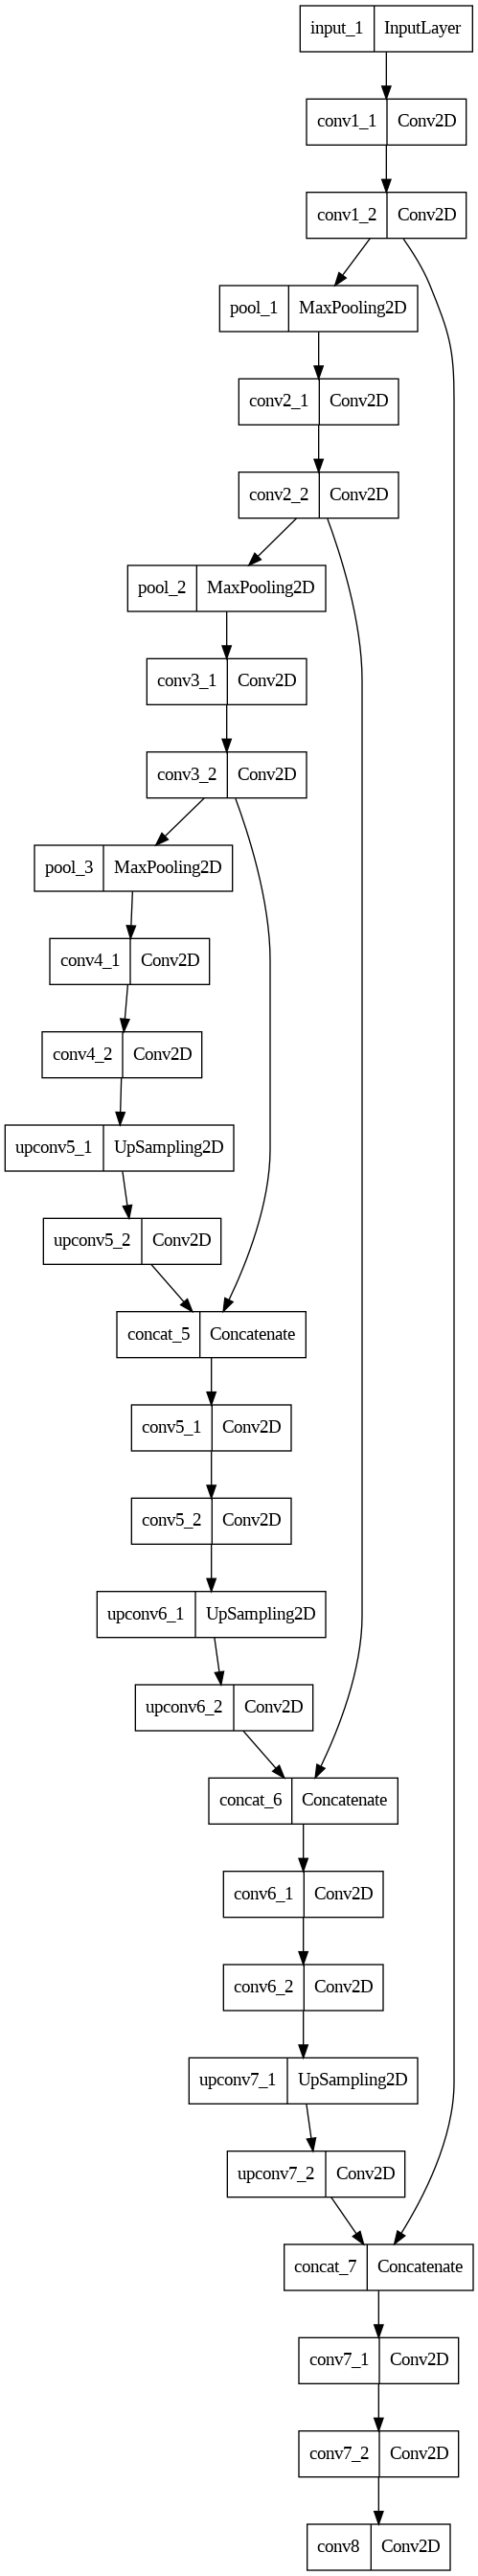

## 2.1. Создайте модель со следующей архитектурой:

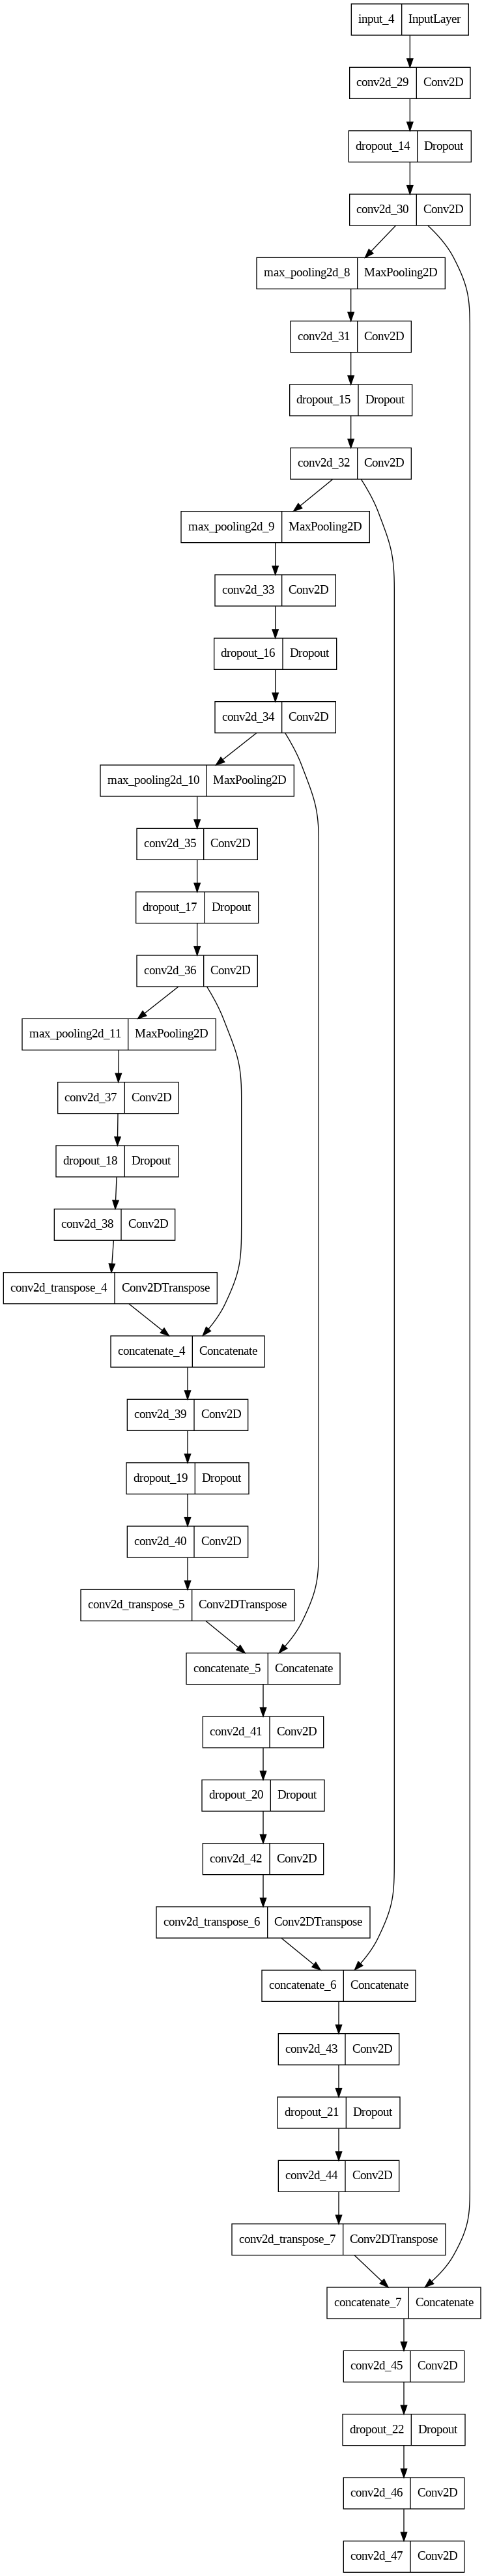

In [ ]:
from keras import Model, Input
from keras.layers import Conv2D, MaxPooling2D, concatenate, UpSampling2D, Dropout, Cropping2D, Softmax, Conv2DTranspose
from keras.preprocessing import image
from keras.utils.vis_utils import plot_model

In [ ]:
def mini_u_net(image_shape, num_of_classes):

    input_image = Input(image_shape)

    # Encoder

    conv1_1 = Conv2D(filters = 16, kernel_size = (3, 3), padding = 'same', activation = 'relu', name = 'conv1_1')(input_image)
    dropout1_1 = Dropout(rate=0.2)(conv1_1)
    conv1_2 = Conv2D(filters = 16, kernel_size = (3, 3), padding = 'same', activation = 'relu', name = 'conv1_2')(dropout1_1)

    pool_1 = MaxPooling2D(pool_size=(2,2), name = 'pool_1')(conv1_2)

    conv2_1 = Conv2D(filters = 32, kernel_size = (3, 3), padding = 'same', activation = 'relu', name = 'conv2_1')(pool_1)
    dropout2_1 = Dropout(rate=0.2)(conv2_1)
    conv2_2 = Conv2D(filters = 32, kernel_size = (3, 3), padding = 'same', activation = 'relu', name = 'conv2_2')(dropout2_1)

    pool_2 = MaxPooling2D(pool_size=(2,2), name = 'pool_2')(conv2_2)

    conv3_1 = Conv2D(filters = 64, kernel_size = (3, 3), padding = 'same', activation = 'relu', name = 'conv3_1')(pool_2)
    dropout3_1 = Dropout(rate=0.2)(conv3_1)
    conv3_2 = Conv2D(filters = 64, kernel_size = (3, 3), padding = 'same', activation = 'relu', name = 'conv3_2')(dropout3_1)

    pool_3 = MaxPooling2D(pool_size=(2,2), name = 'pool_3')(conv3_2)

    conv4_1 = Conv2D(filters = 128, kernel_size = (3, 3), padding = 'same', activation = 'relu', name = 'conv4_1')(pool_3)
    dropout4_1 = Dropout(rate=0.2)(conv4_1)
    conv4_2 = Conv2D(filters = 128, kernel_size = (3, 3), padding = 'same', activation = 'relu', name = 'conv4_2')(dropout4_1)


    pool_4 = MaxPooling2D(pool_size=(2,2), name = 'pool_4')(conv4_2)


    conv5_1 = Conv2D(filters = 256, kernel_size = (3, 3), padding = 'same', activation = 'relu', name = 'conv5_1')(pool_4)
    dropout5_1 = Dropout(rate=0.2)(conv5_1)
    conv5_2 = Conv2D(filters = 256, kernel_size = (3, 3), padding = 'same', activation = 'relu', name = 'conv5_2')(dropout5_1)

    # Decoder

    upconv5_1 = Conv2DTranspose(filters = 128, kernel_size = (2, 2), strides=(2, 2), activation = 'linear', padding = 'same', name = 'upconv5_1')(conv5_2)

    concat_5 = concatenate([upconv5_1, conv4_2], axis = 3, name = 'concat_5') # Split Connections


    conv6_1 = Conv2D(filters = 128, kernel_size = (3, 3), padding = 'same', activation = 'relu', name = 'conv6_1')(concat_5)
    dropout6_1 = Dropout(rate=0.2)(conv6_1)
    conv6_2 = Conv2D(filters = 128, kernel_size = (3, 3), padding = 'same', activation = 'relu', name = 'conv6_2')(dropout6_1)
    upconv6_1 = Conv2DTranspose(filters = 64, kernel_size = (2, 2), strides=(2, 2), activation = 'linear', padding = 'same', name = 'upconv6_1')(conv6_2)

    concat_6 = concatenate([upconv6_1, conv3_2], axis = 3, name = 'concat_6') # Split Connections

    conv7_1 = Conv2D(filters = 64, kernel_size = (3, 3), padding = 'same', activation = 'relu', name = 'conv7_1')(concat_6)
    dropout7_1 = Dropout(rate=0.2)(conv7_1)
    conv7_2 = Conv2D(filters = 64, kernel_size = (3, 3), padding = 'same', activation = 'relu', name = 'conv7_2')(dropout7_1)
    upconv7_1 = Conv2DTranspose(filters = 32, strides=(2, 2), kernel_size = (2, 2), activation = 'relu', padding = 'same', name = 'upconv7_1')(conv7_2)

    concat_7 = concatenate([upconv7_1, conv2_2], axis = 3, name = 'concat_7') # Split Connections

    conv8_1 = Conv2D(filters = 32, kernel_size = (3, 3), padding = 'same', activation = 'relu', name = 'conv8_1')(concat_7)
    dropout8_1 = Dropout(rate=0.2)(conv8_1)
    conv8_2 = Conv2D(filters = 32, kernel_size = (3, 3), padding = 'same', activation = 'relu', name = 'conv8_2')(dropout8_1)
    upconv8_1 = Conv2DTranspose(filters = 16, strides=(2, 2), kernel_size = (2, 2), activation = 'linear', padding = 'same', name = 'upconv8_1')(conv8_2)

    concat_8 = concatenate([upconv8_1, conv1_2], axis = 3, name = 'concat_8') # Split Connections


    conv9_1 = Conv2D(filters = 16, kernel_size = (3, 3), padding = 'same', activation = 'relu', name = 'conv9_1')(concat_8)
    dropout9_1 = Dropout(rate=0.2)(conv9_1)
    conv9_2 = Conv2D(filters = 16, kernel_size = (3, 3), padding = 'same', activation = 'relu', name = 'conv9_2')(dropout9_1)

    conv10 = Conv2D(filters = num_of_classes, kernel_size = (1, 1), activation = 'softmax', name = 'conv10')(conv9_2)

    model = Model(inputs = input_image, outputs = conv10, name = 'model')

    return model

In [ ]:
model_2 = mini_u_net(image_shape = [256, 256, 3], num_of_classes = 5)

In [ ]:
model_2.summary()

Model: "model"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 input_1 (InputLayer)           [(None, 256, 256, 3  0           []                               
                                )]                                                                
                                                                                                  
 conv1_1 (Conv2D)               (None, 256, 256, 16  448         ['input_1[0][0]']                
                                )                                                                 
                                                                                                  
 dropout (Dropout)              (None, 256, 256, 16  0           ['conv1_1[0][0]']                
                                )                                                             

In [ ]:
model_2.get_config()

{'name': 'model',
 'layers': [{'class_name': 'InputLayer',
   'config': {'batch_input_shape': (None, 256, 256, 3),
    'dtype': 'float32',
    'sparse': False,
    'ragged': False,
    'name': 'input_1'},
   'name': 'input_1',
   'inbound_nodes': []},
  {'class_name': 'Conv2D',
   'config': {'name': 'conv1_1',
    'trainable': True,
    'dtype': 'float32',
    'filters': 16,
    'kernel_size': (3, 3),
    'strides': (1, 1),
    'padding': 'same',
    'data_format': 'channels_last',
    'dilation_rate': (1, 1),
    'groups': 1,
    'activation': 'relu',
    'use_bias': True,
    'kernel_initializer': {'class_name': 'GlorotUniform',
     'config': {'seed': None}},
    'bias_initializer': {'class_name': 'Zeros', 'config': {}},
    'kernel_regularizer': None,
    'bias_regularizer': None,
    'activity_regularizer': None,
    'kernel_constraint': None,
    'bias_constraint': None},
   'name': 'conv1_1',
   'inbound_nodes': [[['input_1', 0, 0, {}]]]},
  {'class_name': 'Dropout',
   'config'

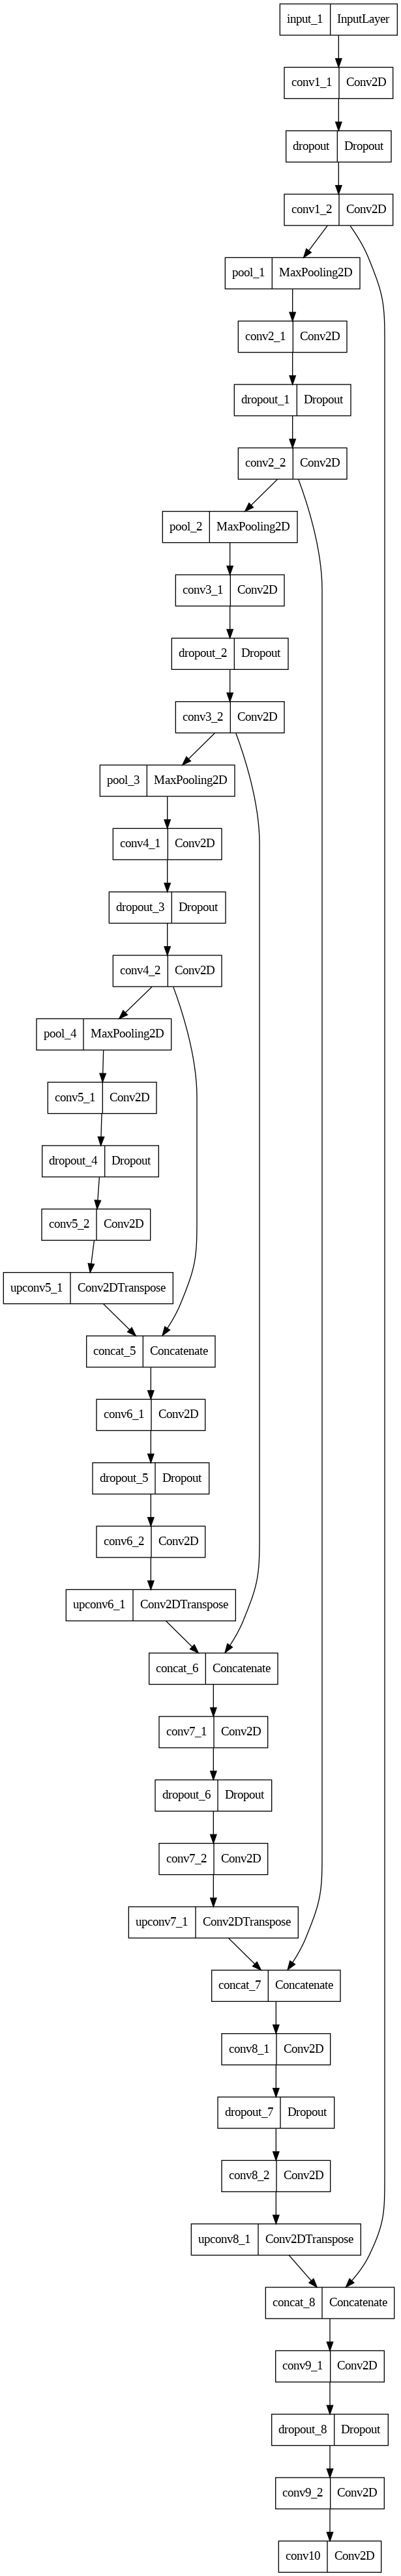

In [ ]:
plot_model(
model_2, to_file='model.png', show_shapes=False, show_dtype=False,
show_layer_names=True, rankdir='TB', expand_nested=False, dpi=96
)

In [ ]:
from keras.models import Model
from keras.layers import Input, Conv2D, Dropout, MaxPooling2D, Conv2DTranspose, concatenate
from keras.optimizers import Adam

In [ ]:
# Компиляция модели
model_2.compile(optimizer=Adam(), loss='categorical_crossentropy', metrics=['accuracy'])


## 2.2. Обучите созданную модель для решения задачи семантической сегментации. В качестве функции потерь используйте ту, которая лучше всего показала себя в задании №1

In [ ]:
history2=model_2.fit(
          train_img_gen,
          steps_per_epoch=steps_per_epoch,
          epochs=1,
          verbose=1,
          validation_data=None)

In [ ]:
model_2 = load_model('/content/drive/MyDrive/model_2.h5')

### 2.2.1. Загрузите три снимка, а также маски, соответствующие этим снимкам

### 2.2.2. Используя обученную модель, обработайте снимки по технологии, рассмотренной на практическом занятии (делим снимок на части, затем каждую часть обрабатываем нейросетью, а после соединяем все части для получения полноразмерной маски исходного снимка)

In [ ]:
# Получение тестового изображения и соответствующей ему маски
test_image_batch, test_mask_batch = train_img_gen.__next__()

# Преобразование маски из категориального формата в формат меток классов
test_mask_batch_argmax = np.argmax(test_mask_batch, axis=3)

# Выполнение предсказания на тестовом изображении
test_pred_batch = model_2.predict(test_image_batch)

# Преобразование предсказания из вероятностного формата в формат меток классов
test_pred_batch_argmax = np.argmax(test_pred_batch, axis=3)

# Количество классов
n_classes = 5

# Инициализация объекта для вычисления среднего IoU
IOU_keras = MeanIoU(num_classes=n_classes)

# Обновление состояния объекта среднего IoU на основе предсказания и истинной маски
IOU_keras.update_state(test_pred_batch_argmax, test_mask_batch_argmax)

# Вывод среднего IoU
print("Mean IoU =", IOU_keras.result().numpy())

1/1 [==============================] - 5s 5s/step
Mean IoU = 0.53421589


### 2.2.3. Загрузите наиболее удачную модель из предыдущего задания (Задания №1). Сравните её точность с моделью, обученной в этом задании:

### 2.2.4. Отобразите предсказанную маску для каждого из трех снимков, загруженных ранее, в следующем формате: (исходный снимок, эталонная маска, предсказанная маска по модели, обученной в этом задании, предсказанная маска по модели, обученной в первом задании.

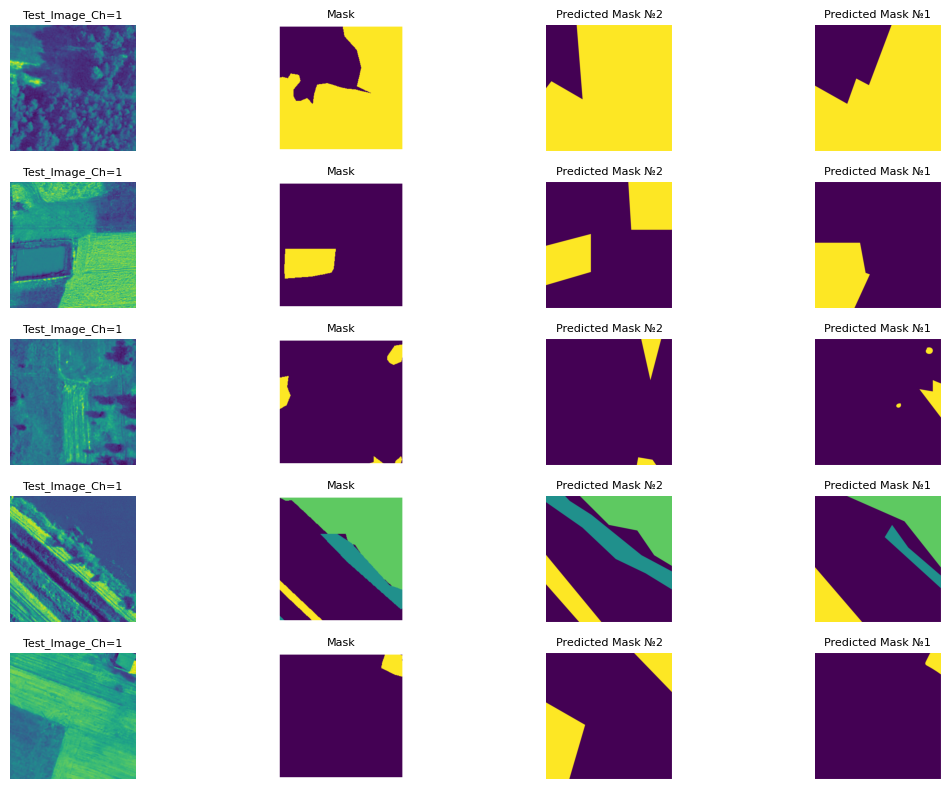

In [ ]:
for img_num in range(5):

    fig=plt.figure(figsize=(12,8), facecolor='w', edgecolor='k')

    figure, axis = plt.subplots(1, 4)
    fig.tight_layout()

    axis[0].imshow(test_image_batch[img_num][:,:,0])
    axis[0].set_title('Test_Image_Ch=1', fontsize = 8)
    axis[0].axes.xaxis.set_visible(False)
    axis[0].axes.yaxis.set_visible(False)

    axis[1].imshow(test_image_batch[img_num][:,:,1])
    axis[1].set_title('Mask', fontsize = 8)
    axis[1].axes.xaxis.set_visible(False)
    axis[1].axes.yaxis.set_visible(False)

    axis[2].imshow(test_mask_batch_argmax[img_num])
    axis[2].set_title("Predicted Mask №2", fontsize = 8)
    axis[2].axes.xaxis.set_visible(False)
    axis[2].axes.yaxis.set_visible(False)

    axis[3].imshow(test_pred_batch_argmax[img_num])
    axis[3].set_title("Predicted Mask №1", fontsize = 8)
    axis[3].axes.xaxis.set_visible(False)
    axis[3].axes.yaxis.set_visible(False)

    plt.show()


# Задание №3. Реализация готового решения для полноразмерной семантической сегментации спутникового снимка

## Реализуйте готовый алгоритм, который принимает на вход полноразмерное изображение и маску (опционально). После чего на его основе формирует полноразмерную маску, предсказанную наиболее удачной моделью нейронной сети, обученной ранее в Задании №1 или Задании №2.

- Сравните получившийся результат с эталонной маской

In [ ]:
import cv2
def pathc_pred(img):
    # Определение размеров изображения, которые кратны размеру патча
    SIZE_X = (img.shape[1]//patch_size)*patch_size  # Ширина изображения
    SIZE_Y = (img.shape[0]//patch_size)*patch_size  # Высота изображения

    # Преобразование массива numpy в объект изображения PIL
    large_img = Image.fromarray(img)

    # Обрезка изображения до размеров, кратных размеру патча
    large_img = large_img.crop((0 ,0, SIZE_X, SIZE_Y))

    # Преобразование объекта изображения PIL обратно в массив numpy
    large_img = np.array(large_img)

    # Разбиение изображения на патчи с использованием функции patchify
    patches_img = patchify(large_img, (patch_size, patch_size, 3), step=patch_size)

    # Удаление лишней оси из массива патчей
    patches_img = patches_img[:,:,0,:,:,:]
    # Инициализация списка для хранения предсказаний на каждом патче
    patched_prediction = []

    # Цикл по каждому патчу изображения
    for i in range(patches_img.shape[0]):
        for j in range(patches_img.shape[1]):

            # Выбор одного патча изображения
            single_patch_img = patches_img[i,j,:,:,:]

            # Нормализация патча изображения с использованием объекта scaler
            single_patch_img = scaler.fit_transform(single_patch_img.reshape(-1, single_patch_img.shape[-1])).reshape(single_patch_img.shape)

            # Добавление дополнительной оси в начало массива для соответствия формату входных данных модели
            single_patch_img = np.expand_dims(single_patch_img, axis=0)

            # Выполнение предсказания модели на патче изображения
            pred = model.predict(single_patch_img)

            # Выбор класса с наибольшей вероятностью в каждом пикселе
            pred = np.argmax(pred, axis=3)

            # Удаление лишней оси из массива предсказания
            pred = pred[0, :,:]

            # Добавление предсказания в список
            patched_prediction.append(pred)

    # Преобразование списка предсказаний в массив numpy
    patched_prediction = np.array(patched_prediction)

    # Изменение формы массива предсказаний, чтобы он соответствовал форме массива патчей изображения
    patched_prediction = np.reshape(patched_prediction, [patches_img.shape[0], patches_img.shape[1],
                                            patches_img.shape[2], patches_img.shape[3]])

    # Объединение патчей предсказаний в одно большое изображение
    unpatched_prediction = unpatchify(patched_prediction, (large_img.shape[0], large_img.shape[1]))


    plt.imshow(unpatched_prediction)
    plt.axis('off')
    plt.savefig("squares1.png",
            bbox_inches ="tight",
            pad_inches = 1,
            transparent = True,
            facecolor ="g",
            edgecolor ='w',
            orientation ='landscape')
    img = cv2.imread("squares1.png")
    return img

- Реализуйте графический интерфейс с помощью Gradio. На вход подается только исходный растр - на выходе отображается сгенерированная маска. Также маска автоматически должна сохраняться в корневом каталоге.

In [ ]:
!pip install -q gradio

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.3/12.3 MB 35.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 92.0/92.0 kB 11.3 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 316.3/316.3 kB 35.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 75.6/75.6 kB 9.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 142.5/142.5 kB 19.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.8/8.8 MB 74.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 47.2/47.2 kB 5.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.4/62.4 kB 7.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 129.9/129.9 kB 16.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 77.9/77.9 kB 8.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.3/58.3 kB 7.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 71.9/71.9 kB 8.5 MB/s e

In [ ]:
import gradio as gr

In [ ]:
interface = gr.Interface(
    fn = pathc_pred,
    inputs = gr.Image(label="Image"),
    outputs = 'image',
    examples = ["/content/drive/MyDrive/content/landcover_ai/images/N-34-66-C-c-4-3.tif"],
)
interface.launch()

Setting queue=True in a Colab notebook requires sharing enabled. Setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
Running on public URL: https://39168f12f50f0de48e.gradio.live

This share link expires in 72 hours. For free permanent hosting and GPU upgrades, run `gradio deploy` from Terminal to deploy to Spaces (https://huggingface.co/spaces)
